Гипотеза: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Докажем это статистически, используя одностороннюю проверку гипотезы с двумя выборками:

Нулевая гипотеза $H_0: \mu_{\text{СПб}} \leq \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге не больше, чем в Москве.

Альтернативная гипотеза $H_1: \mu_{\text{СПб}} > \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

## Анализ активности пользователей сервиса Яндекс Книги: сравнение времени использования в Москве и Санкт-Петербурге.

## Цели и задачи проекта

<font color='#777778'>**Цель проекта:**
    Проверить Проверить гипотезу о том, что пользователи из Санкт-Петербурга проводят больше времени в приложении Яндекс Книги по сравнению с пользователями из Москвы.
    
    
   **Задачи проекта:**
1. Предварительный анализ данных (загрузка, проверка дубликатов, описательная статистика).
2. Статистическая проверка гипотезы с использованием одностороннего t-теста.
3. Интерпретация результатов и формулировка выводов.</font>

## Описание данных

<font color='#777778'>Источник данных: Сервис Яндекс Книги  
Период данных: с 1 сентября по 11 декабря 2024 года  

Набор данных для анализа: **yandex_knigi_data.csv** содержит предобработанные данные пользовательской активности, полученные в результате SQL-запроса.  

**Структура данных:**  

*   **city** - город пользователя (Москва или Санкт-Петербург)  
*   **puid** - уникальный идентификатор пользователя  
*   **hours** - общее количество часов активности пользователя (сумма времени чтения и прослушивания)  

**Целевая переменная:** время активности пользователей в часах **hours**  

**Группы для сравнения:**  
*   **Москва** - пользователи из Москвы  
*   **Санкт-Петербург** - пользователи из Санкт-Петербурга</font>

## Содержимое проекта

<font color='#777778'>5.1. **Загрузка данных и знакомство с ними**. Импорт данных из CSV-файла и первичный анализ структуры.
    
6.2. **Проверка гипотезы в Python**. Подготовка данных, выбор статистического теста, расчёт p-value.
    
7.3. **Аналитическая записка**. Интерпретация результатов, выводы и рекомендации.</font>

---

## 1. Загрузка данных и знакомство с ними

Для анализа данных нам понадобятся несколько библиотек:
- **pandas** для работы с табличными данными
- **numpy** для математических операций
- **matplotlib.pyplot** и **seaborn** для визуализации данных
- **scipy.stats** для статистических тестов

Загрузим эти библиотеки перед началом работы:

In [1]:
# Импортируем необходимые библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

Загружаем данные из файла **yandex_knigi_data.csv**. Этот файл содержит предобработанные данные о пользовательской активности в двух городах: Москве и Санкт-Петербурге. 

Исходные датасеты являются конфиденциальной информацией и не включены в публичный репозиторий.

In [79]:
try:
    # Загружаем CSV-файл с историческими данными
    df = pd.read_csv('/datasets/yandex_knigi_data.csv')
    print("Файл /datasets/yandex_knigi_data.csv успешно загружен")
    
    
except FileNotFoundError:
    # Обработка случая, когда файл не найден
    print("Ошибка: Файл /datasets/yandex_knigi_data.csv не найден по указанному пути")
    print("Проверьте путь к файлу или загрузите файл в рабочую директорию")
    
except Exception as e:
    # Обработка других возможных ошибок (например, проблемы с кодировкой, форматом файла)
    print(f"Произошла ошибка при загрузке файла: {e}")

Файл /datasets/yandex_knigi_data.csv успешно загружен


Начнем знакомство с данными, посмотрим первые 5 строк и информацию о датасете:

In [3]:
# смотрим первые строки датасета
df.head()

,Unnamed: 0,city,puid,hours
0,0,Москва,9668,26.167776
1,1,Москва,16598,82.111217
2,2,Москва,80401,4.656906
3,3,Москва,140205,1.840556
4,4,Москва,248755,151.326434


In [4]:
# смотрим информацию о датасете
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  8784 non-null   int64  
 1   city        8784 non-null   object 
 2   puid        8784 non-null   int64  
 3   hours       8784 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 274.6+ KB


Данные успешно загружены, размерность: 8784 строк × 4 столбца. Основные столбцы **city**, **puid**, **hours**, а так же в данных есть служебный столбец **Unnamed: 0** (вероятно, индекс из CSV). Данные в отличном состоянии: пропуски отсутствуют, типы данных соответствуют ожидаемым: город (object), ID пользователя (int64), часы активности (float64).

Идем дальше, выполним стандартные проверки данных:
- Проверим названия столбцов и их соответствие описанию
- Удалим служебный столбец
- Проверим на дубликаты
- Проверим уникальные значения в категориальных столбцах
- Проверим распределение данных.

In [5]:
# Проверяем названия столбцов
print("Названия столбцов:")
print(df.columns.tolist())

Названия столбцов:
['Unnamed: 0', 'city', 'puid', 'hours']


In [6]:
# Удаляем служебный столбец 'Unnamed: 0'
df = df.drop(columns=['Unnamed: 0'])
print("Столбец 'Unnamed: 0' удален.")

Столбец 'Unnamed: 0' удален.


In [7]:
# Обновленная размерность данных 
df.shape

(8784, 3)

Служебный столбец удален, остальные названия в порядке: единообразие и snake_case. 

In [8]:
# Проверяем на наличие дубликатов по puid (идентификатору пользователя)
duplicates = df['puid'].duplicated().sum()

if duplicates > 0:
    print(f"Количество дубликатов по puid: {duplicates}")
else:
    print("Дубликатов по puid не обнаружено.")

Количество дубликатов по puid: 244


Посмотрим примеры, что там за дубликаты:

In [9]:
# Посмотрим на примеры дублирующихся записей
print("\nПримеры дублирующихся записей (первые 10 дубликатов):")
duplicated_puids = df[df['puid'].duplicated(keep=False)]['puid'].unique()[:10]
for puid in duplicated_puids:
    user_data = df[df['puid'] == puid]
    print(f"\nПользователь {puid}:")
    print(user_data)


Примеры дублирующихся записей (первые 10 дубликатов):

Пользователь 2637041:
                 city     puid      hours
35             Москва  2637041  10.317371
6247  Санкт-Петербург  2637041   3.883926

Пользователь 9979490:
                 city     puid      hours
134            Москва  9979490  32.415573
6274  Санкт-Петербург  9979490   1.302997

Пользователь 10597984:
                 city      puid      hours
145            Москва  10597984  42.931506
6279  Санкт-Петербург  10597984   9.041320

Пользователь 10815097:
                 city      puid     hours
150            Москва  10815097  9.086655
6283  Санкт-Петербург  10815097  0.323291

Пользователь 13626259:
                 city      puid      hours
187            Москва  13626259  21.104167
6300  Санкт-Петербург  13626259   1.648434

Пользователь 16488430:
                 city      puid     hours
230            Москва  16488430  1.502500
6314  Санкт-Петербург  16488430  6.582367

Пользователь 19858636:
                 

О, это меняет дело! Это не технические дубликаты, а пользователи, которые проявляли активность в обоих городах (Москве и Санкт-Петербурге) в течение периода исследования. Каждый из 244 дублирующихся puid соответствует уникальному пользователю, у этих пользователей есть по 2 записи: одна с городом "Москва", другая с "Санкт-Петербург". При этом количество часов активности различается между городами для каждого пользователя.
Что это может быть: люди перемещаются между городами в течение периода исследования и используют приложение в разных географических локациях.

Проверим, есть ли полные дубликаты (одинаковые значения во всех столбцах) и определим, как обрабатывать таких пользователей для корректного сравнения групп.

In [10]:
# Проверяем наличие полных дубликатов (одинаковые значения во всех столбцах)
full_duplicates = df.duplicated().sum()


if full_duplicates > 0:
    print(f"Количество полных дубликатов: {full_duplicates}")
else:
    print("Полных дубликатов не обнаружено.")

Полных дубликатов не обнаружено.


In [11]:
# Анализируем пользователей с активностью в двух городах
dual_city_users = df.groupby('puid')['city'].nunique()
users_in_both_cities = dual_city_users[dual_city_users > 1]

print(f"Количество пользователей с активностью в двух городах: {len(users_in_both_cities)}")
print(f"Это составляет {len(users_in_both_cities)/df['puid'].nunique():.2%} от всех уникальных пользователей")

# Проверяем, есть ли пользователи с более чем 2 записями
users_multiple_records = dual_city_users[dual_city_users > 2]
print(f"Пользователей с более чем 2 записями: {len(users_multiple_records)}")

Количество пользователей с активностью в двух городах: 244
Это составляет 2.86% от всех уникальных пользователей
Пользователей с более чем 2 записями: 0


В итоге: полных дубликатов не обнаружено. Есть особенность данных: 244 пользователя (2.86% от общего числа) проявляли активность в обоих городах (Москве и Санкт-Петербурге), каждый пользователь имеет максимум 2 записи (по одной для каждого города).

Надо решить, что мы с этими пользователями будем делать.

Вариант 1: Отнести к городу с большей активностью в часах (За: так мы сохраняем всех пользователей в анализе (более полные данные) Против: получается искусственное разделение пользователей на группы, а это искажает их реальное поведение. К тому же, юзеры могут быть равномерно активны в обоих городах).

Вариант 2: Удалить таких пользователей (За: получим чистые группы без пересечений, что статистически более корректно для тестов. И избежим двойного учета активности. Против: теряем 244 пользователя (около 2.86% данных), может привести к небольшому смещению выборки.

Поскольку процент таких пользователей невелик (2.86%) и их включение может исказить результаты сравнения независимых групп, более статистически корректно будет исключить этих пользователей из анализа. Это обеспечит чистоту эксперимента и корректность тестов.

In [12]:
# Идентифицируем пользователей с активностью в двух городах
users_in_both_cities_list = users_in_both_cities.index.tolist()

# Создаем чистый датафрейм без пользователей, активных в обоих городах
df_clean = df[~df['puid'].isin(users_in_both_cities_list)].copy()

print(f"Размер данных до очистки: {df.shape}")
print(f"Размер данных после очистки: {df_clean.shape}")
print(f"Удалено записей: {len(df) - len(df_clean)}")

Размер данных до очистки: (8784, 3)
Размер данных после очистки: (8296, 3)
Удалено записей: 488


Проверим еще раз:

In [13]:
# Проверяем, что теперь у каждого пользователя только один город
users_city_check = df_clean.groupby('puid')['city'].nunique()
print(f"Пользователей с более чем одним городом: {(users_city_check > 1).sum()}")

Пользователей с более чем одним городом: 0


У нас получился очищенный датафрейм **df_clean**, который содержит только пользователей, активных в одном городе. Обновим основной датафрейм для удобства дальнейшей работы.

In [14]:
# Обновляем основной датафрейм для дальнейшей работы
df = df_clean.copy()
print(f"Теперь работаем с очищенным датафреймом. Размер: {df.shape}")

Теперь работаем с очищенным датафреймом. Размер: (8296, 3)


In [15]:
# Проверяем уникальные значения в столбце city
df['city'].unique()

array(['Москва', 'Санкт-Петербург'], dtype=object)

In [16]:
# Проверяем распределение пользователей по городам в очищенных данных
print("Распределение пользователей по городам (очищенные данные):")
city_distribution = df['city'].value_counts()
city_distribution

Распределение пользователей по городам (очищенные данные):


Москва             5990
Санкт-Петербург    2306
Name: city, dtype: int64

Посмотрим еще долю:

In [17]:
# Распределение пользователей по городам в долях:
print(f"\nДоля пользователей из Москвы: {city_distribution.get('Москва', 0) / len(df):.2%}")
print(f"Доля пользователей из Санкт-Петербурга: {city_distribution.get('Санкт-Петербург', 0) / len(df):.2%}")


Доля пользователей из Москвы: 72.20%
Доля пользователей из Санкт-Петербурга: 27.80%


Итак, после предобработки мы получили итоговую выборку из 8296 уникальных пользователей (с распределением 72.2% Москва, 27.8% СПб). Данные готовы для статистического анализа.

Теперь изучим основные метрики (средние, медианы, стандартные отклонения) и проанализируем распределения (визуально оценим нормальность и выбросы).

In [18]:
# Разделим данные по городам
moscow_data = df[df['city'] == 'Москва']['hours']
spb_data = df[df['city'] == 'Санкт-Петербург']['hours']

print(f"Москва: {len(moscow_data)} пользователей")
print(f"Санкт-Петербург: {len(spb_data)} пользователей")

Москва: 5990 пользователей
Санкт-Петербург: 2306 пользователей


In [19]:
# Изучим основные метрики по группам

# Создадим сводную таблицу с ключевыми метриками
metrics_summary = pd.DataFrame()

for city_name, data in [('Москва', moscow_data), ('Санкт-Петербург', spb_data)]:
    metrics = {
        'Количество пользователей': len(data),
        'Среднее (часов)': data.mean(),
        'Медиана (часов)': data.median(),
        'Стандартное отклонение': data.std(),
        'Минимум': data.min(),
        'Максимум': data.max(),
        'Доля от общей выборки': f"{len(data)/len(df):.1%}"
    }
    metrics_summary[city_name] = pd.Series(metrics)

metrics_summary

,Москва,Санкт-Петербург
Количество пользователей,5990,2306
Среднее (часов),10.848192,11.264433
Медиана (часов),0.888232,0.875355
Стандартное отклонение,36.925622,39.831755
Минимум,0.000022,0.000025
Максимум,857.209373,978.764775
Доля от общей выборки,72.2%,27.8%


Визуализируем эти данные. Сначала построим гистограммы:

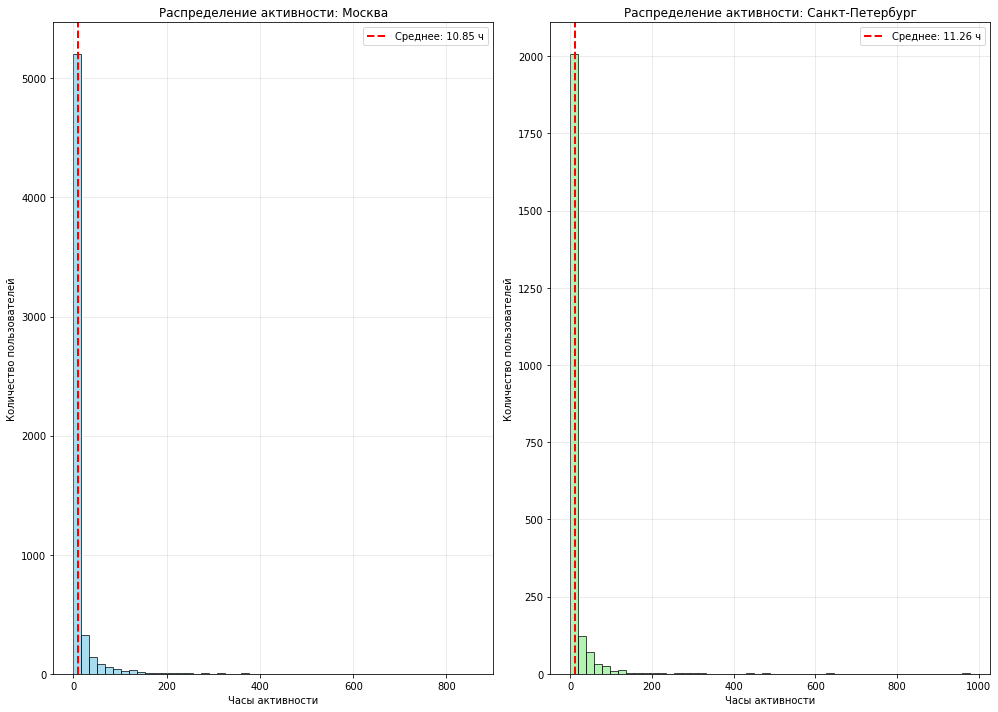

In [20]:
# Распределения Мск и СПб
fig, axes = plt.subplots(1, 2, figsize=(14, 10))

# Гистограмма для Москвы
axes[0].hist(moscow_data, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0].axvline(moscow_data.mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Среднее: {moscow_data.mean():.2f} ч')
axes[0].set_xlabel('Часы активности')
axes[0].set_ylabel('Количество пользователей')
axes[0].set_title('Распределение активности: Москва')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Гистограмма для Санкт-Петербурга
axes[1].hist(spb_data, bins=50, alpha=0.7, color='lightgreen', edgecolor='black')
axes[1].axvline(spb_data.mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Среднее: {spb_data.mean():.2f} ч')
axes[1].set_xlabel('Часы активности')
axes[1].set_ylabel('Количество пользователей')
axes[1].set_title('Распределение активности: Санкт-Петербург')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Видим хвост, строим еще ящики с усами:

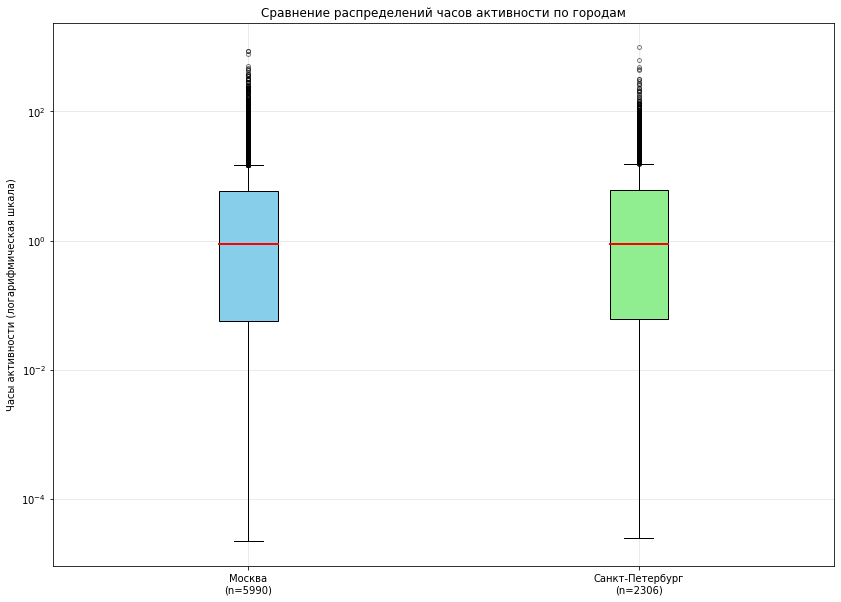

In [21]:
# Строим диаграммы размаха
plt.figure(figsize=(14, 10))
box_data = [moscow_data, spb_data]
box_labels = [f'Москва\n(n={len(moscow_data)})', f'Санкт-Петербург\n(n={len(spb_data)})']

box_plot = plt.boxplot(box_data, labels=box_labels, patch_artist=True,
                       boxprops=dict(color='black'),
                       medianprops=dict(color='red', linewidth=2),
                       flierprops=dict(marker='o', markersize=4, alpha=0.5))

# Закрашиваем боксы разными цветами
colors = ['skyblue', 'lightgreen']
for patch, color in zip(box_plot['boxes'], colors):
    patch.set_facecolor(color)

plt.yscale('log')  # добавим логарифмическую шкалу для наглядности
plt.ylabel('Часы активности (логарифмическая шкала)')
plt.title('Сравнение распределений часов активности по городам')
plt.grid(True, alpha=0.3)
plt.show()

Что мы видим? 
- Распределения сильно скошены вправо: большинство пользователей малоактивны (медианы около 0.89 часов), но есть небольшое количество высокоактивных пользователей (выбросы).
- Средние значения выше медиан (Москва: среднее 10.85ч, медиана 0.89ч; СПб: среднее 11.26ч, медиана 0.88ч). Это подтверждает правостороннюю асимметрию. Разница в средних небольшая, СПб всего на 0.42 часа активнее Москвы (относительная разница: +3.8%)
- Выбросы есть в обеих группах (видны как множество точек на диаграмме размаха выше "усов". При этом максимальные значения очень высокие (до 978ч)
- Размеры выборок разные (Москва: 5990 пользователей (72.2%), СПб: 2306 пользователей (27.8%)). Это важно для выбора статистического теста!

И что же нам надо выяснить? Является ли разница в средних (0.42 часа) статистически значимой, учитывая большие стандартные отклонения и нестандартные распределения?

## 2. Проверка гипотезы в Python

Гипотеза звучит так: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

## 3. Аналитическая записка
По результатам анализа данных подготовьте аналитическую записку, в которой опишете:

- Выбранный тип t-теста и уровень статистической значимости.

- Результат теста, или p-value.

- Вывод на основе полученного p-value, то есть интерпретацию результатов.

- Одну или две возможные причины, объясняющие полученные результаты.



**Выберем статистический тест и обоснуем выбор.**

Что мы поняли после анализа данных:
    - Неравные размеры выборок (Москва (5990), СПб (2306) разница в 2.6 раза)
    - Неравные дисперсии (стандартные отклонения разные Москва 36.93, СПб 39.83)
    - Распределения не нормальные, есть сильная правосторонняя асимметрия (средние гораздо больше медиан)
    - В обеих группах есть выбросы (экстремально активные пользователи)

Получается, классический t-тест сразу отпадает
- Требует нормальности распределений (не выполняется)
- Предполагает равенство дисперсий (не выполняется)
- Чувствителен к выбросам (есть выбросы)

В итоге выбираем между t-тестом Уэлча (не требует равенства дисперсий, работает с неравными размерами выборок, но чувствителен к сильным отклонениям от нормальности) и непараметрическим тестом Манна-Уитни (не требует нормальности распределений, устойчив к выбросам, работает с неравными размерами выборок. Но он сравнивает медианы, а не средние)

**Выбираем основным t-тест Уэлча, но дополнительно проверим тестом Манна-Уитни.**

Потому что t-тест Уэлча это стандартный выбор для сравнения средних при неравных дисперсиях. 
А тест Манна-Уитни проведем дополнительно для проверки устойчивости результатов.

Выберем уровень значимости α = 0.05, как стандартный для бизнес-аналитики.

Тесты будем проводить односторонние greater, потому что:
- в задании четко сказано: "Пользователи из Санкт-Петербурга проводят в среднем больше времени..."
- это же повторяется в самой формулировке гипотезы:
H₀: μ_СПб ≤ μ_Москва (активность СПб не больше Москвы)
H₁: μ_СПб > μ_Москва (активность СПб больше Москвы)
- с точки зрения бизнеса нас интересует именно "больше", а не просто "различается". Если активность в СПб окажется меньше, это не подтверждает гипотезу.

In [22]:
# t-тест Уэлча (односторонний)
from scipy.stats import ttest_ind

"""
ПРОВЕРКА ГИПОТЕЗЫ:
H₀: Средняя активность в СПб НЕ БОЛЬШЕ, чем в Москве (μ_СПб ≤ μ_Москва)
H₁: Средняя активность в СПб БОЛЬШЕ, чем в Москве (μ_СПб > μ_Москва)

Односторонний тест, потому что проверяем конкретное утверждение "СПб активнее"
"""

t_stat, p_value = ttest_ind(spb_data, moscow_data, equal_var=False, alternative='greater') 

print(f"p-value: {p_value:.4f}")

# Определяем статистическую значимость
alpha = 0.05
print(f"Уровень значимости (α): {alpha}")         
          
# Интерпретация результатов
if p_value > alpha:
    print(f"p-value ({p_value:.4f}) > α ({alpha})")
    print("Принимаем нулевую гипотезу: среднее количество часов активности НЕ различается статистически значимо между группами")
else:
    print(f"p-value ({p_value:.4f}) ≤ α ({alpha})")
    print("Отвергаем нулевую гипотезу: среднее количество часов активности различается статистически значимо между группами")

p-value: 0.3318
Уровень значимости (α): 0.05
p-value (0.3318) > α (0.05)
Принимаем нулевую гипотезу: среднее количество часов активности НЕ различается статистически значимо между группами


In [23]:
# Дополнительная проверка: непараметрический тест Манна-Уитни
from scipy.stats import mannwhitneyu

"""
ПРОВЕРКА ГИПОТЕЗЫ (Манна-Уитни):
H₀: Распределение активности в СПб НЕ сдвинуто вправо относительно Москвы
H₁: Распределение активности в СПб сдвинуто вправо относительно Москвы

Тест сравнивает не средние, а целиком распределения.
Односторонний, потому что проверяем "СПб активнее".
"""

u_stat, p_value_mw = mannwhitneyu(spb_data, moscow_data, alternative='greater')

print(f"p-value: {p_value_mw:.4f}")

# Определяем статистическую значимость
alpha = 0.05

if p_value_mw > alpha:
    print(f"p-value ({p_value_mw:.4f}) > α ({alpha})")
    print("Принимаем нулевую гипотезу: распределение активности в СПб НЕ сдвинуто вправо относительно Москвы")
    print("Нет статистически значимых различий в распределениях активности")
else:
    print(f"p-value ({p_value_mw:.4f}) ≤ α ({alpha})")
    print("Отвергаем нулевую гипотезу: распределение активности в СПб сдвинуто вправо относительно Москвы")
    print("Активность в СПб статистически значимо выше")

p-value: 0.4532
p-value (0.4532) > α (0.05)
Принимаем нулевую гипотезу: распределение активности в СПб НЕ сдвинуто вправо относительно Москвы
Нет статистически значимых различий в распределениях активности


Итак, что мы имеем:
- T-тест Уэлча: p-value = 0.3318
- Тест Манна-Уитни: p-value = 0.4532
- Разница в средних: СПб активнее на 0.42 часа (+3.8% относительно Москвы)

**Статистический вывод:**
Оба p-value значительно превышают уровень значимости α = 0.05 и это значит, что статистически значимых различий в пользовательской активности между Москвой и Санкт-Петербургом не обнаружено.Нулевая гипотеза (H₀: активность в СПб не больше, чем в Москве) не отвергается.

Хотя пользователи Санкт-Петербурга демонстрируют несколько более высокую среднюю активность (11.26 часов против 10.85 часов в Москве), эта разница не является статистически значимой (p > 0.05) и не имеет практической значимости для бизнеса (разница 0.42 часа на пользователя).

На что нужно обратить внимание при оценке результатов:
- Пользовательское поведение в двух мегаполисах действительно может быть схожим из-за схожих социально-демографических характеристик аудитории, уровня урбанизации и доступности сервиса.
- В данных присутствуют экстремально активные пользователи (выбросы), которые могут "перетягивать" средние значения, но не отражают поведение типичного пользователя.
- Возможны погрешности в измерении активности или географической привязке пользователей.

**ИТОГОВЫЙ ВЫВОД ПО ПРОЕКТУ:**

Наша гипотеза не подтвердилась. Пользователи из Санкт-Петербурга **НЕ** проводят заметно больше времени в приложении Яндекс Книги по сравнению с пользователями из Москвы.

**Что мы узнали из исследования:**

1. **Нет статистически значимой разницы** в активности между Москвой и Санкт-Петербургом
2. **Маленькая практическая разница:** СПб всего на 0.42 часа активнее, это слишком мало, чтобы что-то менять в бизнесе
3. **Пользователи ведут себя похоже** в обоих городах

**РЕКОМЕНДАЦИИ ДЛЯ БИЗНЕСА:**

Не нужно делать разную стратегию для Москвы и СПб на основе активности пользователей. Они ведут себя практически одинаково. Лучше сосредоточиться на общих улучшениях для всей платформы, а не придумывать что-то отдельное для каждого города.

Что можно изучить дальше:
- Как активность зависит от возраста и пола пользователей
- Какие жанры книг популярны в разных группах
- В какое время суток пользователи чаще читают
- Меняется ли активность в разные сезоны года

Особое внимание стоит уделить суперактивным пользователям. Тем, кто проводит в приложении очень много времени, можно предложить специальные программы лояльности, бонусы или премиум-контент.

**Итог:** Яндекс Книги одинаково хорошо работают и в Москве, и в Санкт-Петербурге. Это значит, что успешные решения можно применять в обоих городах, а в будущем - и в других регионах.